In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../dataset.csv")
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


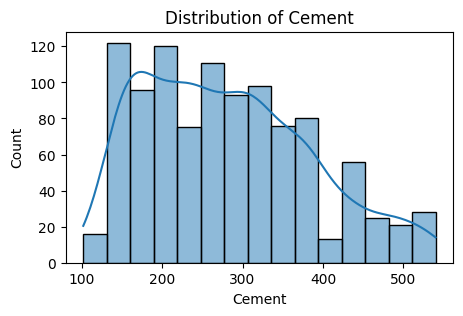

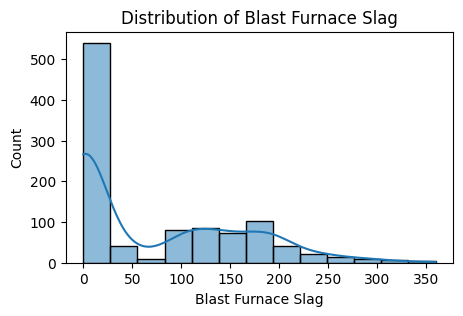

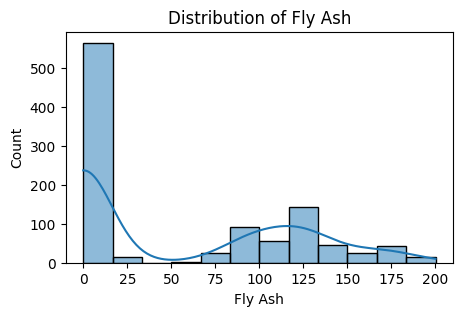

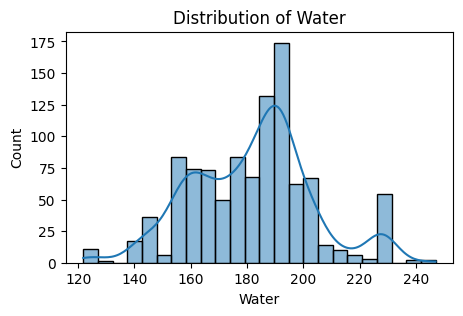

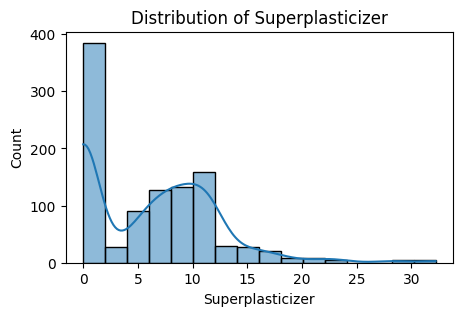

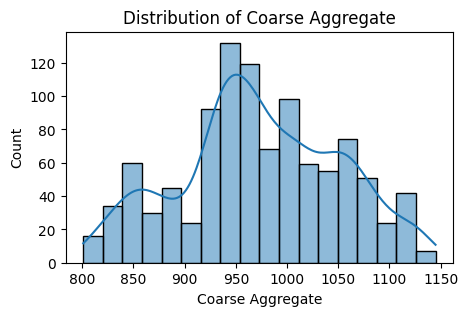

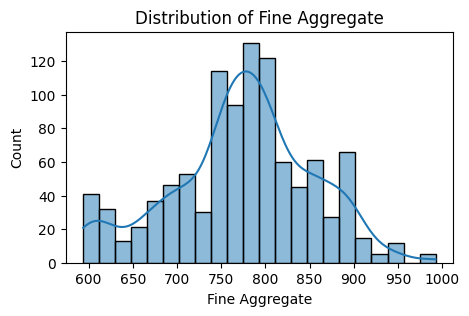

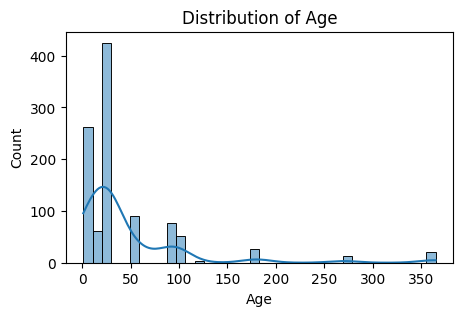

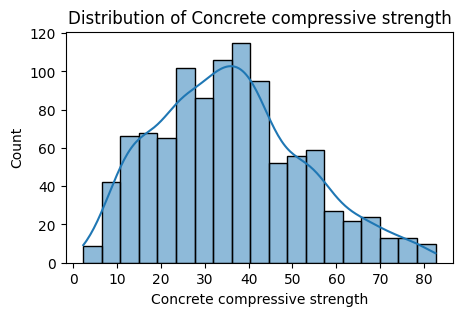

In [31]:
for col in df.columns:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

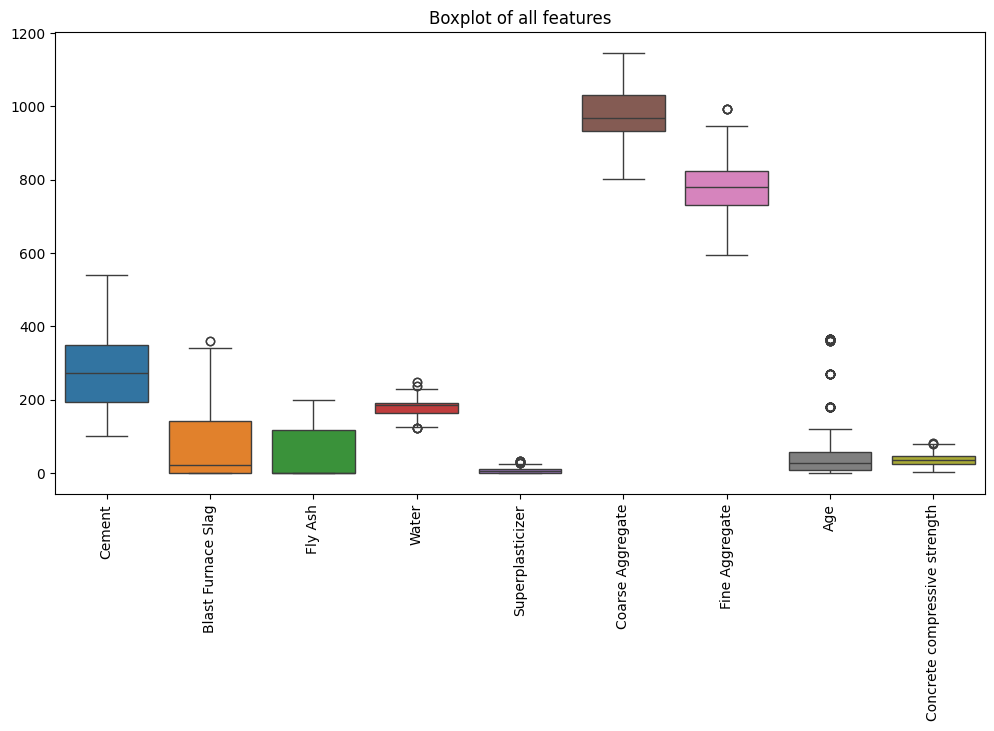

In [32]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot of all features")
plt.show()

In [33]:
outlier_counts = {}

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = len(outliers)

outlier_counts

{'Cement': 0,
 'Blast Furnace Slag': 2,
 'Fly Ash': 0,
 'Water': 9,
 'Superplasticizer': 10,
 'Coarse Aggregate': 0,
 'Fine Aggregate': 5,
 'Age': 59,
 'Concrete compressive strength': 4}

In [34]:
sorted_outliers = sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)
sorted_outliers[:3]

[('Age', 59), ('Superplasticizer', 10), ('Water', 9)]

In [35]:
skewness = df.skew().sort_values(ascending=False)
skewness

,0
Age,3.269177
Superplasticizer,0.907203
Blast Furnace Slag,0.800717
Fly Ash,0.537354
Cement,0.509481
Concrete compressive strength,0.416977
Water,0.074628
Coarse Aggregate,-0.040220
Fine Aggregate,-0.253010


In [36]:
skewness.head(3)

,0
Age,3.269177
Superplasticizer,0.907203
Blast Furnace Slag,0.800717


## Skewness Analysis

- The most skewed features are:
  - Age (highly positively skewed)
  - Superplasticizer (moderately skewed)
  - Blast Furnace Slag (moderately skewed)

- Age shows strong right skew, indicating many low values and a few very large values.

## Preprocessing Recommendations

- Make all values similar in scale so model works better
- Fix highly skewed features like Age using transformation
- Remove or adjust extreme values (outliers)
- Avoid using features that give similar information